# This notebooks performs EDA of the dataset

## Loading and first glance at the dataset

### Import packages

In [9]:
import os
from pathlib import Path
root_dir = Path('/workspaces/droneRF-c/')
os.chdir(root_dir)
import pandas as pd
import numpy as np
from scipy.signal import spectrogram

import matplotlib.pyplot as plt



### Load the raw csv file

In [10]:
data_root = root_dir / 'data/raw/DroneRF'
data_category = 'Phantom drone'

csv_files = list((data_root / data_category).rglob('*.csv'))
print(os.getcwd())
print(data_root / data_category)
print(len(csv_files))
print(csv_files[:5])  # preview
print('='*50)

print(csv_files)

/workspaces/droneRF-c
/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone
42
[PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_L1/11000L_2.csv'), PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_L1/11000L_6.csv'), PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_L1/11000L_9.csv'), PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_L1/11000L_0.csv'), PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_L1/11000L_5.csv')]
[PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_L1/11000L_2.csv'), PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_L1/11000L_6.csv'), PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_L1/11000L_9.csv'), PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_L1/11000L_0.csv'), PosixPath('/workspaces/droneRF-c/data/raw/Drone

In [11]:
# Build two dicts: {index: path}
h_files = {}
l_files = {}

for f in csv_files:
    name = f.stem        # e.g. '11000H_3' or '11000L_10'
    idx = int(name.split('_')[1])
    if 'H' in name:
        h_files[idx] = f
    elif 'L' in name:
        l_files[idx] = f

common_idx = sorted(set(h_files.keys()) & set(l_files.keys()))
print(h_files)
print(l_files)

{20: PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_H/11000H_20.csv'), 17: PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_H/11000H_17.csv'), 9: PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_H/11000H_9.csv'), 4: PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_H/11000H_4.csv'), 0: PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_H/11000H_0.csv'), 7: PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_H/11000H_7.csv'), 8: PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_H/11000H_8.csv'), 15: PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_H/11000H_15.csv'), 12: PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_H/11000H_12.csv'), 1: PosixPath('/workspaces/droneRF-c/data/raw/DroneRF/Phantom drone/RF Data_11000_H/11000H_1.csv'), 6

### Reshape the sequence and check  

In [1]:

interval = 5000
def from_csv_to_spectrogram(file_idx, file_dict, N1=0, N2=100000):
    df = pd.read_csv(file_dict[file_idx], header=None, usecols=range(N1, N2))
    df_array = np.array(df)
    df_reshaped = df_array.copy().reshape(-1, 2)
    complex_signal = df_reshaped[:, 0] + 1j * df_reshaped[:, 1]
    fft = np.fft.fftshift(complex_signal)
    f, t, Sxx = spectrogram(complex_signal, fs=40e6, return_onesided=False)
    f = np.fft.fftshift(f)
    Sxx = np.fft.fftshift(Sxx, axes=0)
    return {'f':f, 't':t, 'Sxx':Sxx, 'fft':fft}
l_info = from_csv_to_spectrogram(1, l_files, N, N+interval)
h_info = from_csv_to_spectrogram(1, l_files, 500000, N+interval)
print(l_info.keys())

NameError: name 'l_files' is not defined

In [ ]:
# print(f'complex signal shape {l_info['complex_signal'].shape}, {l_info['complex_signal'].dtype}')
print(f'fft shape: {l_info['fft'].shape}, {l_info['fft'].dtype}')
print(f'f shape: {l_info['f'].shape}, {l_info['f'].dtype}')
print(f't shape: {l_info['t'].shape}, {l_info['t'].dtype}')
print(f'Sxx shape: {l_info['Sxx'].shape}, {l_info['Sxx'].dtype}')

fft shape: (2500,), complex128
f shape: (256,), float64
t shape: (11,), float64
Sxx shape: (256, 11), float64


### Visualize spectrogram

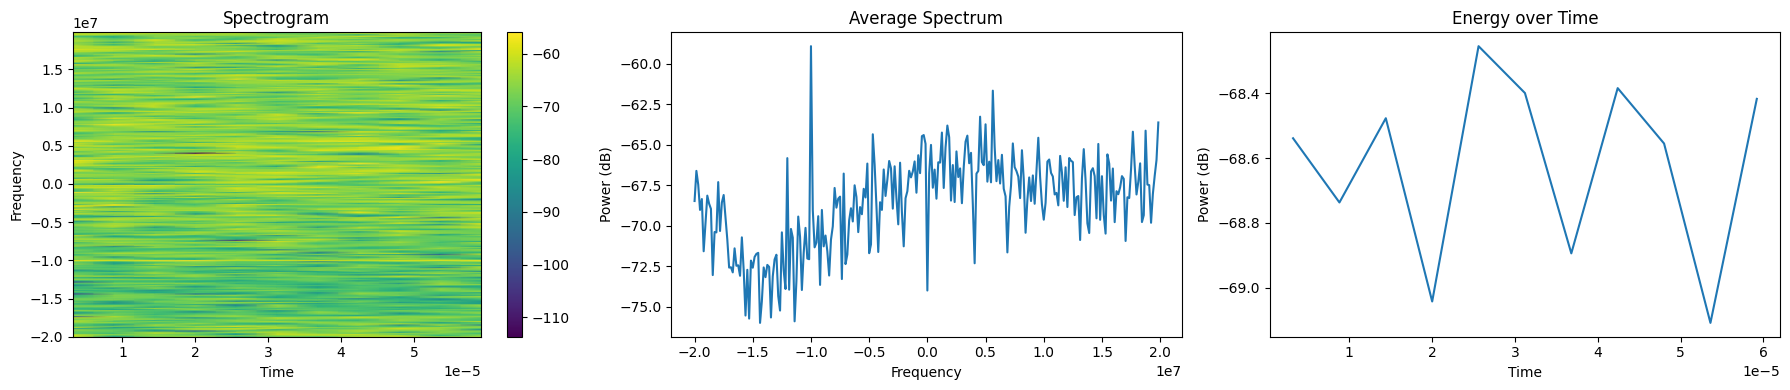

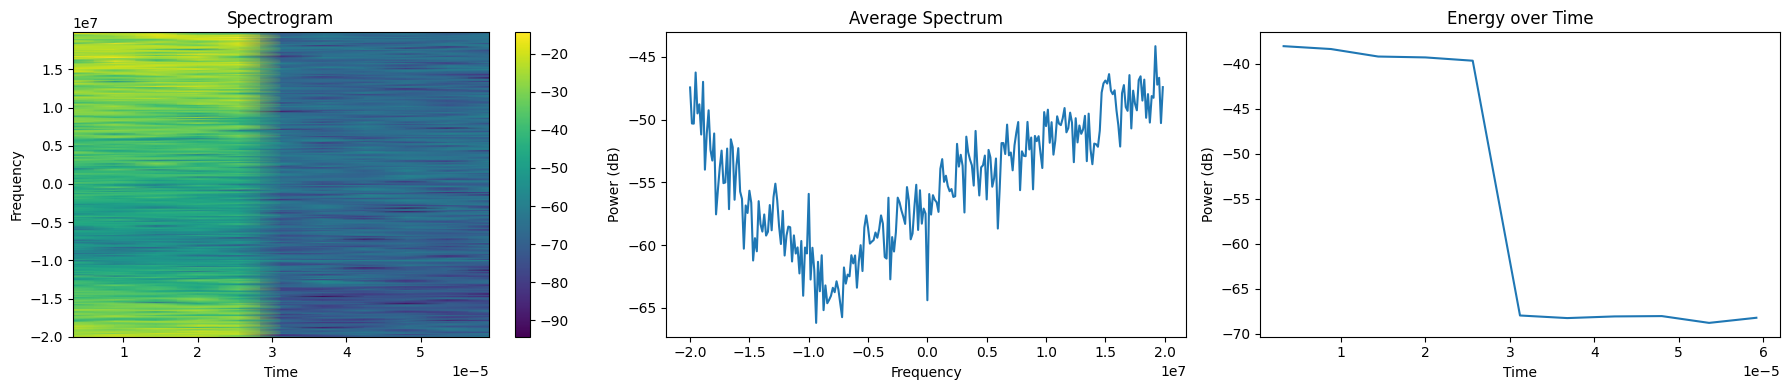

In [14]:
def visualize_spectrogram(lh_info):    
# Convert to dB (avoid log(0))
    Sxx_db = 10 * np.log10(lh_info['Sxx'] + 1e-12)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # --- (1) Spectrogram ---
    im = axes[0].pcolormesh(lh_info['t'], lh_info['f'], Sxx_db, shading='gouraud')
    axes[0].set_title("Spectrogram")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Frequency")
    fig.colorbar(im, ax=axes[0])

    # --- (2) Frequency slice (average over time) ---
    axes[1].plot(lh_info['f'], Sxx_db.mean(axis=1))
    axes[1].set_title("Average Spectrum")
    axes[1].set_xlabel("Frequency")
    axes[1].set_ylabel("Power (dB)")

    # --- (3) Time slice (average over frequency) ---
    axes[2].plot(lh_info['t'], Sxx_db.mean(axis=0))
    axes[2].set_title("Energy over Time")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Power (dB)")

    plt.tight_layout()
    plt.show()
visualize_spectrogram(l_info)
visualize_spectrogram(h_info)

In [ ]:
Plot_N = 1000

In [ ]:
fft_mag = np.abs(fft)[:Plot_N]
fft_db = 20 * np.log10(fft_mag + 1e-12)
plt.plot(fft_db)
plt.title("FFT Spectrum (dB)")
plt.xlabel("Frequency Bin")
plt.ylabel("Magnitude (dB)")
plt.show()

In [ ]:
plt.plot(np.abs(complex_signal)[:Plot_N])
plt.title("Signal Magnitude (Time Domain)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
plt.plot(complex_signal.real[:Plot_N], label="I")
plt.plot(complex_signal.imag[:Plot_N], label="Q", alpha=0.7)
plt.legend()
plt.title("I/Q Components")
plt.show()

In [ ]:
plt.scatter(complex_signal.real[:Plot_N], complex_signal.imag[:Plot_N], s=1)
plt.title("Constellation (I vs Q)")
plt.xlabel("I")
plt.ylabel("Q")
plt.axis('equal')
plt.show()